In [24]:
import tensorflow as tf
import keras
import numpy as np
import pandas as pd
import sklearn
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df = pd.read_csv("data/Combined Data.csv")

print(df.shape)
print(df.columns.tolist())
df.head()

(53043, 3)
['Unnamed: 0', 'statement', 'status']


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [26]:
print(df.describe())

         Unnamed: 0
count  53043.000000
mean   26521.000000
std    15312.339501
min        0.000000
25%    13260.500000
50%    26521.000000
75%    39781.500000
max    53042.000000


In [27]:
df = df.drop(columns=['Unnamed: 0'])

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   statement  52681 non-null  object
 1   status     53043 non-null  object
dtypes: object(2)
memory usage: 828.9+ KB


In [29]:
df = df.dropna(subset=['statement'])
df = df.dropna(subset=['status'])

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52681 entries, 0 to 53042
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   statement  52681 non-null  object
 1   status     52681 non-null  object
dtypes: object(2)
memory usage: 1.2+ MB


In [31]:
df.drop_duplicates(inplace=True)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51093 entries, 0 to 52840
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   statement  51093 non-null  object
 1   status     51093 non-null  object
dtypes: object(2)
memory usage: 1.2+ MB


In [14]:
print(df['status'].value_counts())

status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64


In [15]:
print(df['status'].value_counts(normalize=True) * 100)

status
Normal                  31.022570
Depression              29.240144
Suicidal                20.219814
Anxiety                  7.291054
Bipolar                  5.271350
Stress                   4.910689
Personality disorder     2.044380
Name: proportion, dtype: float64


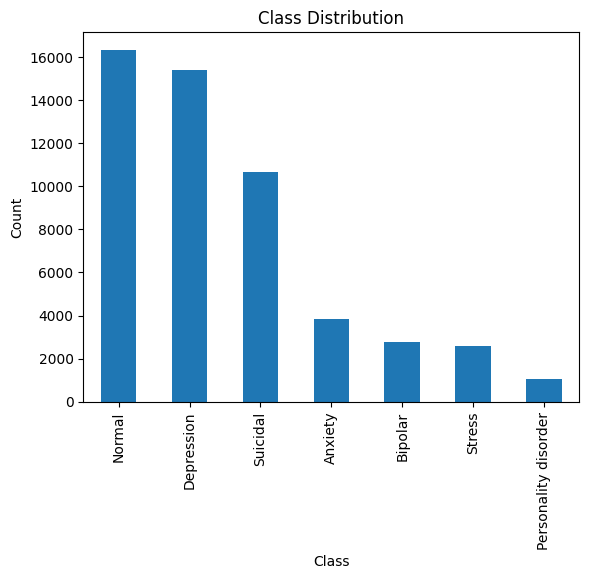

In [16]:
import matplotlib.pyplot as plt

df['status'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [33]:
#label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['status'] = le.fit_transform(df['status'])

In [34]:
df.head()

,statement,status
0,oh my gosh,0
1,"trouble sleeping, confused mind, restless hear...",0
2,"All wrong, back off dear, forward doubt. Stay ...",0
3,I've shifted my focus to something else but I'...,0
4,"I'm restless and restless, it's been a month n...",0


In [35]:
import string
import nltk
import re

nltk.download("stopwords")
nltk.download("wordnet")

from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ziadr/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\ziadr/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [36]:
STOPWORDS = set(stopwords.words("english"))

# IMPORTANT for mental health meaning
STOPWORDS.discard("not")
STOPWORDS.discard("no")

In [37]:
punc = string.punctuation

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', punc))

In [38]:
def clean_text(text):
    # handle missing values
    text = str(text)
    
    # lowercase
    text = text.lower()
    
    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # remove numbers & special characters (extra safety)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # remove stopwords
    words = text.split()
    words = [word for word in words if word not in STOPWORDS]
    
    return " ".join(words)

In [39]:
df["clean_statement"] = df["statement"].apply(clean_text)

In [40]:
print(df[["statement", "clean_statement"]].head())

                                           statement  \
0                                         oh my gosh   
1  trouble sleeping, confused mind, restless hear...   
2  All wrong, back off dear, forward doubt. Stay ...   
3  I've shifted my focus to something else but I'...   
4  I'm restless and restless, it's been a month n...   

                                     clean_statement  
0                                            oh gosh  
1  trouble sleeping confused mind restless heart ...  
2  wrong back dear forward doubt stay restless re...  
3  ive shifted focus something else im still worried  
4                im restless restless month boy mean  


In [45]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet

nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\ziadr/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\ziadr/nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to C:\Users\ziadr/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\ziadr/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ziadr/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [42]:
def get_wordnet_pos(treebank_tag):
    """Convert treebank POS tags to WordNet POS tags"""
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [43]:
def lemmatize_words(text):
    """Lemmatize with POS tagging"""
    tokens = word_tokenize(text.lower())
    pos_tags = nltk.pos_tag(tokens)
    
    lemmatized = []
    for word, pos in pos_tags:
        wordnet_pos = get_wordnet_pos(pos)
        lemma = lemmatizer.lemmatize(word, pos=wordnet_pos)
        lemmatized.append(lemma)
    
    return ' '.join(lemmatized)

In [46]:
df["clean_statement"] = df["clean_statement"].apply(lemmatize_words)

In [47]:
print(df[["statement", "clean_statement"]].head())

                                           statement  \
0                                         oh my gosh   
1  trouble sleeping, confused mind, restless hear...   
2  All wrong, back off dear, forward doubt. Stay ...   
3  I've shifted my focus to something else but I'...   
4  I'm restless and restless, it's been a month n...   

                                     clean_statement  
0                                            oh gosh  
1     trouble sleep confuse mind restless heart tune  
2  wrong back dear forward doubt stay restless re...  
3      ive shift focus something else im still worry  
4                im restless restless month boy mean  


In [73]:
X = df["clean_statement"].values
y = df["status"].values

In [74]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [77]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=100)
X_test_pad = pad_sequences(X_test_seq, maxlen=100)

In [79]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_reshaped = X_train_pad.reshape(X_train_pad.shape[0], -1)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_reshaped, y_train)
X_train_balanced = X_train_balanced.reshape(-1, 100)

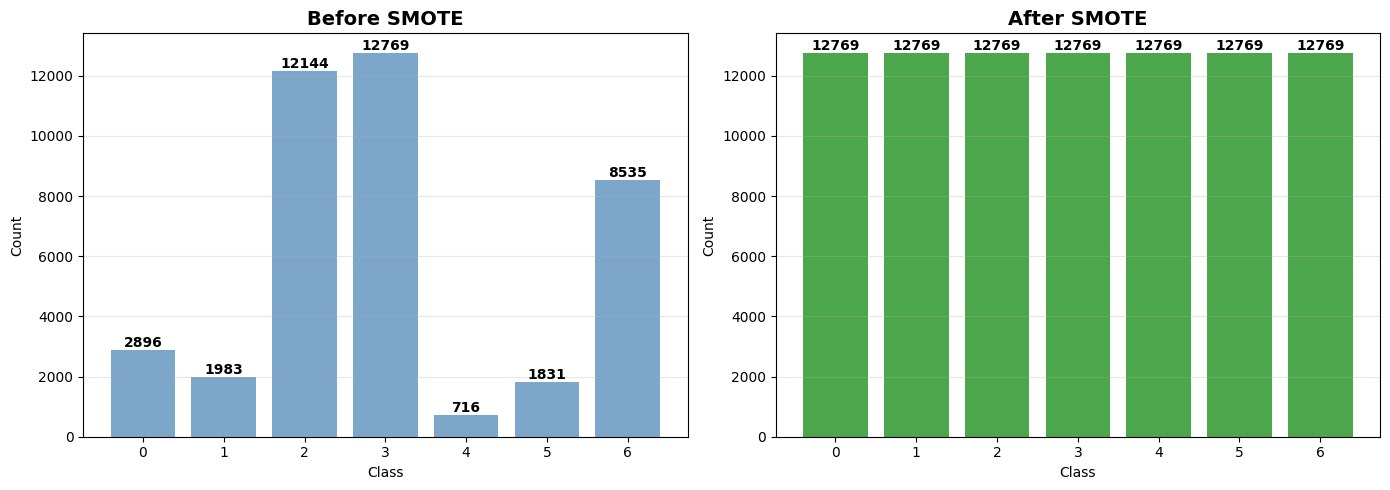

In [80]:
before_counts = np.bincount(y_train)
after_counts = np.bincount(y_train_balanced)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(before_counts)), before_counts, color='steelblue', alpha=0.7)
axes[0].set_title('Before SMOTE', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(before_counts):
    axes[0].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

axes[1].bar(range(len(after_counts)), after_counts, color='green', alpha=0.7)
axes[1].set_title('After SMOTE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(after_counts):
    axes[1].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('smote_comparison.png', dpi=300, bbox_inches='tight')
plt.show()